# *Group 1* - Data Investigative Project Exploratory Data Analysis

## EDA of Firearm Laws and Mass Shootings in the U.S. (2015-2023)

**Ayushi Mody, Arly Siu, Arianna Villarreal, Sevana Zadoian**

In [3]:
# dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression, LogisticRegression
from sklearn.model_selection import KFold
# from sklearn.decomposition import PCA
import sklearn.linear_model as linear
import sklearn.svm as svm
import sklearn.tree as tree
import sklearn.ensemble as ensemble
import sklearn.neighbors as neighbors
import sklearn.metrics as metrics

import seaborn as sns
!pip install geopandas
!pip install rtree
import geopandas as gpd
!pip install fiona
!pip install plotly
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
from IPython.display import display, HTML # makes the output in Jupyter notebook pretty
import plotly.express as px
import json
import os

# Encoding *Giffords Annual Gun Law Scorecard*

**The following two cells are how we encoded the Giffords Annual Gun Law Scorecard. The raw historical data for scoring was not publicly available, so we hard coded the A-F scale rankings on our previously decided integer scale (1-5). Plus/minus distinctions were normalized to just their letter grades.**

In [4]:
giffords_2015 = {
    'Year': [2015]*50,

    'State': [
        'California','Connecticut','New Jersey','Maryland','Massachusetts',
        'New York','Hawaii','Illinois','Rhode Island','Delaware',
        'Washington','Minnesota','Pennsylvania','Oregon','Michigan',
        'Colorado','Iowa','Wisconsin','Ohio','Virginia',
        'Nebraska','New Hampshire','Indiana','West Virginia','Oklahoma',
        'North Carolina','Nevada','South Carolina','Georgia','Florida',
        'North Dakota','Tennessee','New Mexico','Texas','Maine',
        'Alabama','Montana','Arkansas','Utah','South Dakota',
        'Missouri','Vermont','Kentucky','Louisiana','Idaho',
        'Alaska','Arizona','Wyoming','Mississippi','Kansas'
    ],

    'Rank': [5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2,
             1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],

    'Gun Death Rate Rank': [
        42,47,45,36,49,
        48,50,40,46,32,
        39,43,27,28,22,
        25,41,35,29,33,
        38,44,18,13,8,
        21,16,11,20,23,
        24,10,9,31,30,
        4,5,6,19,34,
        12,37,17,2,14,
        1,15,7,3,26
    ]
}

giffords_2016 = {
    'Year': [2016]*50,

    'State': [
        'California','Connecticut','New Jersey','Massachusetts','Maryland',
        'New York','Hawaii','Illinois','Rhode Island','Washington',
        'Delaware','Minnesota','Pennsylvania','Colorado','Oregon',
        'Iowa','Michigan','Nevada','Wisconsin','Nebraska',
        'Ohio','Virginia','New Hampshire','Indiana','North Carolina',
        'Florida','Oklahoma','Tennessee','Georgia','New Mexico',
        'North Dakota','South Carolina','Utah','Texas','West Virginia',
        'Maine','Alabama','Arkansas','Montana','South Dakota',
        'Vermont','Kentucky','Louisiana','Alaska','Wyoming',
        'Idaho','Arizona','Kansas','Missouri','Mississippi'
    ],

    'Rank': [
        5,5,5,5,5,5,5,   # A range
        4,4,4,           # B range
        3,3,3,3,3,3,3,   # C range
        2,2,2,2,2,2,2,   # D range
        *([1]*26)        # F range
    ],

    'Gun Death Rate Rank': [
        43,46,45,50,27,
        48,49,39,47,37,
        24,44,32,22,30,
        42,29,14,35,41,
        26,34,40,21,23,
        25,8,12,16,7,
        20,10,19,28,17,
        36,3,11,6,33,
        38,13,2,1,4,
        15,18,31,9,5
    ]
}

giffords_2017 = {
    'Year': [2017]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Rank': [
        1,1,1,1,5,
        3,5,4,1,1,
        5,1,4,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,2,2,1,5,
        1,5,2,1,2,
        1,3,3,4,1,
        1,2,1,1,1,
        2,4,2,3,1
    ],

    'Gun Death Rate Rank': [
        2,1,16,9,43,
        20,46,37,28,17,
        47,19,34,18,39,
        23,13,3,42,32,
        50,27,44,4,7,
        6,40,15,38,45,
        8,48,21,30,25,
        5,33,31,49,10,
        22,14,28,24,36,
        29,41,12,35,11
    ]
}
giffords_2018 = {
    'Year': [2018]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Rank': [
        1,1,1,1,5,
        3,5,4,3,1,
        5,1,4,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,3,2,1,5,
        1,5,2,2,2,
        1,3,4,4,1,
        1,2,1,2,2,
        2,4,1,3,1
    ],

    'Gun Death Rate Rank': [
        2,1,18,7,44,
        24,46,36,28,19,
        50,15,31,20,41,
        17,16,4,35,29,
        49,37,43,5,6,
        3,42,14,40,45,
        10,48,23,25,22,
        13,47,26,47,12,
        33,11,27,21,34,
        32,38,9,39,8
    ]
}
giffords_2019 = {
    'Year': [2019]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Rank': [
        1,1,1,1,5,
        3,5,4,3,1,
        5,1,5,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,3,4,1,5,
        3,5,2,1,2,
        1,3,4,4,1,
        1,2,1,2,2,
        2,4,1,3,1
    ],

    'Gun Death Rate Rank': [
        2,7,18,8,44,
        19,45,34,27,17,
        48,16,36,20,42,
        21,14,4,39,33,
        49,26,43,1,3,
        13,41,10,37,46,
        6,47,23,35,25,
        15,32,29,50,12,
        22,11,30,24,28,
        31,38,9,40,5
    ]
}
giffords_2020 = {
    'Year': [2020]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Rank': [
        1,1,1,1,5,
        3,5,4,3,1,
        5,1,5,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,3,4,1,5,
        3,5,2,1,2,
        1,3,4,4,1,
        1,2,1,2,2,
        2,4,1,3,1
    ],

    'Gun Death Rate Rank': [
        5,1,16,9,44,
        18,45,40,26,14,
        47,19,35,20,42,
        21,17,6,34,28,
        50,31,43,2,7,
        10,38,15,37,48,
        4,49,23,29,22,
        11,30,32,46,8,
        24,12,27,25,41,
        33,36,13,39,3
    ]
}

In [5]:
giffords_2021 = {
    'Year': [2021]*50,

    'State': [
        'California', 'New Jersey', 'Connecticut', 'Hawaii', 'Illinois',
        'Maryland', 'Massachusetts', 'New York', 'Colorado', 'Delaware',
        'Rhode Island', 'Virginia', 'Washington', 'Oregon', 'Pennsylvania',
        'Michigan', 'Minnesota', 'Nevada', 'New Mexico', 'Florida',
        'Nebraska', 'North Carolina', 'Vermont', 'Wisconsin', 'Ohio',
        'Indiana', 'Alabama', 'Alaska', 'Arizona', 'Arkansas',
        'Georgia', 'Idaho', 'Iowa', 'Kansas', 'Kentucky',
        'Louisiana', 'Maine', 'Mississippi', 'Missouri', 'Montana',
        'New Hampshire', 'North Dakota', 'Oklahoma', 'South Carolina', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        3, 3, 3, 3, 2,
        2, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 48, 45, 50, 27,
        33, 49, 46, 22, 25,
        47, 34, 39, 35, 31,
        24, 43, 18, 7, 29,
        41, 21, 37, 36, 23,
        17, 5, 6, 20, 8,
        15, 16, 38, 19, 13,
        22, 40, 1, 4, 11,
        42, 28, 12, 9, 32,
        10, 26, 30, 14, 3
    ]
}

giffords_2022 = {
    'Year': [2022]*50,

    'State': [
        'California', 'New Jersey', 'Connecticut', 'Hawaii', 'Illinois',
        'Maryland', 'Massachusetts', 'New York', 'Oregon', 'Rhode Island',
        'Washington', 'Colorado', 'Delaware', 'Virginia', 'Pennsylvania',
        'Michigan', 'Minnesota', 'Nevada', 'New Mexico', 'Nebraska',
        'North Carolina', 'Florida', 'Vermont', 'Wisconsin', 'Alabama',
        'Alaska', 'Arizona', 'Arkansas', 'Georgia', 'Idaho',
        'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Mississippi', 'Missouri', 'Montana', 'New Hampshire',
        'North Dakota', 'Ohio', 'Oklahoma', 'South Carolina', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        3, 3, 3, 2, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        43, 48, 45, 49, 26,
        29, 50, 47, 30, 46,
        39, 18, 23, 32, 31,
        28, 42, 15, 3, 41,
        21, 34, 38, 36, 4,
        6, 17, 8, 14, 25,
        16, 40, 20, 13, 22,
        37, 1, 9, 7, 44,
        22, 24, 12, 11, 33,
        10, 27, 35, 19, 5
    ]
}

giffords_2023 = {
    'Year': [2023]*50,

    'State': [
        'California', 'Connecticut', 'New Jersey', 'Colorado', 'Hawaii',
        'Illinois', 'Maryland', 'Massachusetts', 'New York', 'Oregon',
        'Washington', 'Delaware', 'Rhode Island', 'Virginia', 'Minnesota',
        'Pennsylvania', 'Michigan', 'Nevada', 'Vermont', 'New Mexico',
        'Wisconsin', 'Nebraska', 'North Carolina', 'Florida', 'Indiana',
        'Maine', 'New Hampshire', 'Ohio', 'South Carolina', 'Alabama',
        'Alaska', 'Arizona', 'Arkansas', 'Georgia', 'Idaho',
        'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Mississippi',
        'Missouri', 'Montana', 'North Dakota', 'Oklahoma', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 5, 5,
        5, 4, 4, 4, 4,
        4, 4, 4, 4, 3,
        3, 3, 3, 2, 2,
        2, 2, 2, 2, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 45, 47, 19, 48,
        32, 35, 49, 46, 30,
        36, 39, 50, 28, 43,
        29, 27, 15, 38, 3,
        33, 37, 20, 31, 17,
        40, 42, 26, 9, 4,
        7, 12, 8, 14, 18,
        41, 21, 16, 22, 1,
        6, 5, 22, 13, 24,
        10, 25, 34, 23, 11
    ]
}

giffords_2024 = {
    'Year': [2024]*50,

    'State': [
        'California', 'Connecticut', 'Massachusetts', 'New Jersey', 'New York',
        'Colorado', 'Delaware', 'Hawaii', 'Illinois', 'Maryland',
        'Oregon', 'Rhode Island', 'Washington', 'Virginia', 'Minnesota',
        'Pennsylvania', 'Michigan', 'Nevada', 'New Mexico', 'Vermont',
        'Maine', 'Wisconsin', 'Florida', 'Nebraska', 'North Carolina',
        'Indiana', 'New Hampshire', 'Ohio', 'Alabama', 'Alaska',
        'Arizona', 'Arkansas', 'Georgia', 'Idaho', 'Iowa',
        'Kansas', 'Kentucky', 'Louisiana', 'Mississippi', 'Missouri',
        'Montana', 'North Dakota', 'Oklahoma', 'South Carolina', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        2, 2, 2, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 45, 50, 49, 48,
        20, 39, 46, 32, 37,
        26, 47, 33, 29, 43,
        31, 28, 15, 4, 38,
        27, 35, 30, 40, 21,
        17, 42, 23, 3, 5,
        14, 7, 13, 18, 41,
        22, 16, 22, 1, 10,
        9, 34, 11, 12, 36,
        6, 24, 25, 19, 8
    ]
}

giffords_2025 = {
    'Year': [2025]*50,

    'State': [
        'California', 'New Jersey', 'Connecticut', 'New York', 'Massachusetts',
        'Illinois', 'Hawaii', 'Maryland', 'Washington', 'Colorado',
        'Oregon', 'Rhode Island', 'Delaware', 'Virginia', 'Minnesota',
        'Pennsylvania', 'Michigan', 'Vermont', 'Nevada', 'New Mexico',
        'Maine', 'Wisconsin', 'Nebraska', 'Florida', 'North Carolina',
        'Indiana', 'Texas', 'Utah', 'South Carolina', 'Ohio',
        'Tennessee', 'North Dakota', 'West Virginia', 'New Hampshire', 'Iowa',
        'Alabama', 'Louisiana', 'Oklahoma', 'Alaska', 'Georgia',
        'Arizona', 'Kansas', 'Mississippi', 'South Dakota', 'Montana',
        'Idaho', 'Missouri', 'Kentucky', 'Arkansas', 'Wyoming'
    ],

    'Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        2, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 48, 45, 47, 49,
        30, 50, 38, 39, 21,
        25, 46, 37, 28, 43,
        34, 33, 41, 17, 2,
        35, 32, 40, 29, 19,
        16, 26, 27, 11, 24,
        9, 31, 22, 42, 36,
        4, 6, 12, 3, 14,
        18, 23, 1, 15, 8,
        20, 10, 13, 7, 5
    ]
}

# Creating Historical Ranking Data

**In the following cell, we turned all the raw data from the Giffords Scorecards into DataFrames and concatenated them together into a total DataFrame called `giffords_2015_to_2025`. This DataFrame's granularity is a state in a year, with the respective rankings and Gun Death Rate Rank included as well. As we continue our EDA, this DataFrame will be used to understand severity measures in firearm policies.**

In [6]:
giffords_2015_to_2025 = pd.concat([
    pd.DataFrame(giffords_2015),
    pd.DataFrame(giffords_2016),
    pd.DataFrame(giffords_2017),
    pd.DataFrame(giffords_2018),
    pd.DataFrame(giffords_2019),
    pd.DataFrame(giffords_2020),
    pd.DataFrame(giffords_2021),
    pd.DataFrame(giffords_2022),
    pd.DataFrame(giffords_2023),
    pd.DataFrame(giffords_2024),
    pd.DataFrame(giffords_2025)
], ignore_index=True)

# Adding in State Control per Year

**In the following cell, we added in the state control of each state for each year. State control is "when the same party holds both legislative chambers and the governorship". We hope to see if state control can be an indicator for whether new laws restricting gun use will be passed.**

In [7]:
statecontrol_2015 = {
  'Year': [2015]*50,
  'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota',  'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'D', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'S',
        'R', 'S', 'R', 'S', 'S',
        'S', 'R', 'S', 'R', 'S',
        'S', 'N/A', 'R', 'S', 'S',
        'S', 'S', 'R', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'D',
        'S', 'S', 'S', 'R', 'R'
    ]
}

statecontrol_2016 = {
  'Year': [2016]*50,
  'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'D', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'S',
        'R', 'R', 'S', 'S', 'S',
        'S', 'R', 'S', 'R', 'S',
        'S', 'N/A', 'R', 'S', 'S',
        'S', 'S', 'R', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'D',
        'S', 'S', 'S', 'R', 'R'
    ]
}

statecontrol_2017 = {
    'Year': [2017]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'S', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'R',
        'R', 'R', 'S', 'S', 'S',
        'S', 'R', 'S', 'R', 'R',
        'S', 'N/A', 'S', 'R', 'S',
        'S', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'S', 'R', 'R'
    ]
}

statecontrol_2018 = {
    'Year': [2018]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'S', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'R',
        'R', 'R', 'S', 'S', 'S',
        'S', 'R', 'S', 'R', 'R',
        'S', 'N/A', 'S', 'R', 'D',
        'S', 'S', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'R', 'R'
    ]
}

statecontrol_2019 = {
    'Year': [2019]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'R', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'S', 'N/A', 'D', 'S', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2020 = {
    'Year': [2020]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'R', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'S', 'N/A', 'D', 'S', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'D', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2021 = {
    'Year': [2021]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'R', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'R', 'N/A', 'D', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'D', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2022 = {
    'Year': [2022]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'R', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'R', 'N/A', 'D', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2023 = {
    'Year': [2023]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'D',
        'D', 'D', 'D', 'R', 'R',
        'R', 'N/A', 'S', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2024 = {
    'Year': [2024]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'R', 'D', 'D',
        'D', 'S', 'D', 'R', 'R',
        'R', 'N/A', 'S', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2025 = {
    'Year': [2025]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'R', 'S', 'D',
        'D', 'S', 'S', 'R', 'R',
        'R', 'N/A', 'S', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}


# Creating a State Control Data Frame

**In the following cell, we turned all the raw data from the National COnference of State Legislatures into DataFrames and concatenated them together into a total DataFrame called `statecontrol_2015_to_2025`. This DataFrame's granularity is a state in a year, with the respective state control included. We will go forward and join this with the Giffords Scorecard data to add more contect to our later models.**

In [8]:
statecontrol_2015_to_2025 = pd.concat([
    pd.DataFrame(statecontrol_2015),
    pd.DataFrame(statecontrol_2016),
    pd.DataFrame(statecontrol_2017),
    pd.DataFrame(statecontrol_2018),
    pd.DataFrame(statecontrol_2019),
    pd.DataFrame(statecontrol_2020),
    pd.DataFrame(statecontrol_2021),
    pd.DataFrame(statecontrol_2022),
    pd.DataFrame(statecontrol_2023),
    pd.DataFrame(statecontrol_2024),
    pd.DataFrame(statecontrol_2025)
], ignore_index=True)

# Putting together the Data Frames

**Using pd.merge in order to put together the Giffords data with the NCSL data. Using merge instead of join because we are using both the year and state columns and don't want to create redundancies.**

In [41]:
merged_pd = pd.merge(giffords_2015_to_2025, statecontrol_2015_to_2025, on=["State", "Year"], how="inner")

# Visualization 1 - Folium Map of Giffords Over Time

In the following cell, we took the concatenated Giffords Scorecards DataFrame to create a Folium Map of the scoring of the states over time. It has a 'Tooltip' that showcases the information of each state when they are hovered over, and includes the death rate by firearm per state ranked from 1-50.**

In [42]:
import pandas as pd
import folium
import json
import copy
from folium.plugins import TimestampedGeoJson
from google.colab import files
import requests

#uploaded = files.upload()

geojson_data = requests.get('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/us-states.json').json()

giffords_2015_to_2025 = giffords_2015_to_2025[giffords_2015_to_2025['Year'] >= 2015]

years = sorted(giffords_2015_to_2025['Year'].unique())

features = []

for _, row in giffords_2015_to_2025.iterrows():
    year = row['Year']
    next_year = year + 1

    for feature in geojson_data['features']:
        if feature['properties']['name'] == row['State']:
            feature_copy = copy.deepcopy(feature)

            val = (row['Rank'] - 1) / 4

            r = int(255 * (1 - val))
            g = 0
            b = int(255 * val)

            feature_copy['properties'] = {
                'times': [f'{year}-01-01', f'{next_year}-01-01'],
                'style': {
                    'color': 'black',
                    'weight': 1,
                    'fillColor': f'rgba({r},{g},{b},0.7)',
                    'fillOpacity': 0.7
                },
                'tooltip': (
                    f"<b>{row['State']}</b><br>"
                    f"Year: {year}<br>"
                    f"Rank: {row['Rank']}<br>"
                    f"Gun Death Rate Rank: {row['Gun Death Rate Rank']}"
                ),
                'popup': (
                    f"{row['State']} ({year})<br>"
                    f"Rank: {row['Rank']}<br>"
                    f"Gun Death Rate Rank: {row['Gun Death Rate Rank']}"
                )
            }

            features.append(feature_copy)

m = folium.Map(location=[37.8, -96], zoom_start=4)

TimestampedGeoJson(
    {
        'type': 'FeatureCollection',
        'features': features
    },
    period='P1Y',
    add_last_point=False,
    auto_play=True,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options='YYYY',
    time_slider_drag_update=True
).add_to(m)

legend_html = '''
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 200px; height: 120px;
background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
padding: 10px;
">
<b>Rank Legend</b><br>
<i style="background:rgb(255,0,0);width:20px;height:10px;display:inline-block;"></i> Rank 1 (Lowest)<br>
<i style="background:rgb(128,0,128);width:20px;height:10px;display:inline-block;"></i> Rank 3<br>
<i style="background:rgb(0,0,255);width:20px;height:10px;display:inline-block;"></i> Rank 5 (Highest)
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

m

# *RAND Gun Policy In America State Firearm Law Database*

**The following cell is used to load the dataset that will guide our research into the different firearm laws that exist in the 50 states. We uploaded `firearm_laws.csv`, which we downloaded from the RAND Database, to a GitHub repo, and restricted the dataset to the years we are observing (2015 to present). The dataset is updated through 2023, so there are bound to be NaN values from 2024-2025 in the merged DataFrame.**

In [43]:
rand_df = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/firearm_laws.csv')
rand_df = rand_df[rand_df['year'] >= 2015]

# Visualization 2 - Firearm Laws in the U.S. Over Time

**We created a simple line plot of the number of total firearm laws that existed in all states during our interval of years. We can see that between 2015 and 2023, over 100 new firearm laws were passed across the country, with 2017-2019 being a significant turning point, as over 60 laws were passed.**

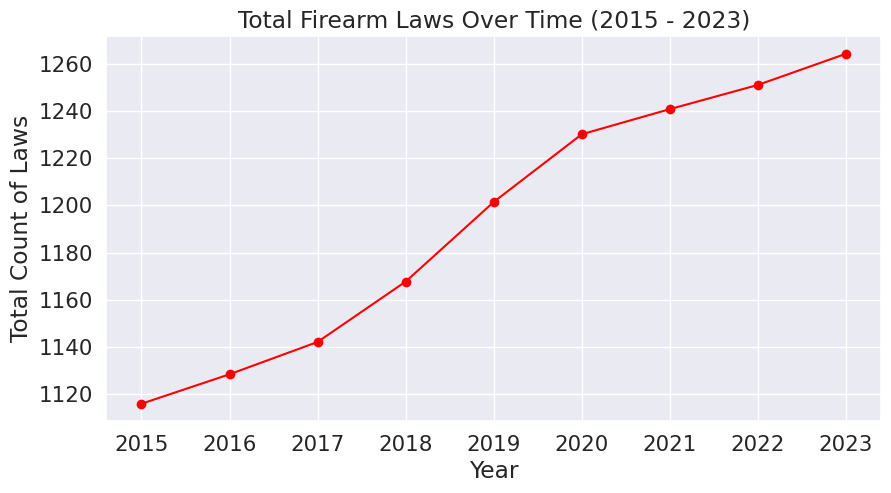

In [44]:
time_series = rand_df.groupby('year')['year_frac'].sum()
plt.figure(figsize = (10, 5))
time_series.plot(marker = 'o', color = 'red')
plt.xlabel('Year')
plt.ylabel('Total Count of Laws')
plt.title('Total Firearm Laws Over Time (2015 - 2023)')
plt.grid(True)

In [45]:
laws_by_state_year = rand_df.groupby(['state', 'year', 'law_class'])['year_frac'].sum().reset_index().rename(columns={'year_frac': 'law_count'})
law_and_rank = pd.merge(giffords_2015_to_2025, laws_by_state_year, left_on=['State', 'Year'], right_on=['state', 'year']).drop(columns=['state', 'year'])

# Loading in Mass Shooting Data

**The following 3 cells were used to load in data on mass shootings from the Gun Violence Archive. In the first cell we downloaded the most recent data and restricted it from 2023 to 2025, in the second we downloaded the individual datasets from the years 2015-2022, and in the third we combined our individual datasets to create one large DataFrame that will guide our analysis.**

In [46]:
ms_2025_to_2023 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_2026_to_2023.csv')
ms_2025_to_2023['Incident Date'] = pd.to_datetime(ms_2025_to_2023['Incident Date'])
ms_2025_to_2023['Year'] = ms_2025_to_2023['Incident Date'].dt.year
ms_2025_to_2023 = ms_2025_to_2023[(ms_2025_to_2023['Year'] >= 2023) & (ms_2025_to_2023['Year'] <= 2025)]

In [47]:
ms_2022 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2022.csv')
ms_2021 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2021.csv')
ms_2020 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2020.csv')
ms_2019 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2019.csv')
ms_2018 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2018.csv')
ms_2017 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2017.csv')
ms_2016 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_2016.csv')
ms_2015 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_2015.csv')

In [48]:
ms_2015_2022 = pd.concat([
    ms_2022, ms_2021,
    ms_2020, ms_2019,
    ms_2018, ms_2017,
    ms_2016, ms_2015
], ignore_index=True)
ms_2015_2022['Incident Date'] = pd.to_datetime(ms_2015_2022['Incident Date'])
ms_2015_2022['Year'] = ms_2015_2022['Incident Date'].dt.year
mass_shootings = pd.concat([ms_2025_to_2023, ms_2015_2022])
mass_shootings = mass_shootings.drop(columns=['Operations'])

# Summary Table Combining *Giffords Annual Gun Law Scorecard* with *RAND* Laws

**The following table combines our datasets to better understand the summary statistics for the main variables used in our analysis, especially between the count of laws and the general rank and death rate ranking. The dataset consists of state-year observations from 2015 to 2023. The main outcome variable is the number of mass shootings per state-year (`Num Mass Shootings`), with additional measures capturing severity through the number of victims killed (`Num Killed`) and injured (`Num Injured`). The key explanatory variable is the number of firearm laws (`law_count`), which reflects the total number of active laws weighted by the fraction of the year they were in effect. The dataset also includes state rankings of gun law strength (`Rank`) and gun death rates (`Gun Death Rate Rank`).**

In [49]:
#count incidents per state-year
ms_state_year = mass_shootings.groupby(['State', 'Year']).size().reset_index(name='Num Mass Shootings')

#count killings per state-year
ms_state_year['Num Killed'] = mass_shootings.groupby(['State','Year'])['Victims Killed'].sum().values

#count injured per state-year
ms_state_year['Num Injured'] = mass_shootings.groupby(['State','Year'])['Victims Injured'].sum().values

laws_total = (law_and_rank.groupby(['State','Year','Rank','Gun Death Rate Rank'])['law_count'].sum().reset_index())

ms_state_year_laws = pd.merge(laws_total, ms_state_year, on=['State','Year'], how='left')

ms_state_year_laws[['Num Mass Shootings','Num Killed','Num Injured']] = ms_state_year_laws[['Num Mass Shootings','Num Killed','Num Injured']].fillna(0)

In [50]:
ms_state_year_laws[['law_count', 'Num Mass Shootings', 'Num Killed', 'Num Injured', 'Rank', 'Gun Death Rate Rank']].describe()

,law_count,Num Mass Shootings,Num Killed,Num Injured,Rank,Gun Death Rate Rank
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,23.022447,9.655556,9.888889,39.973333,2.366667,25.675556
std,10.978676,12.396890,13.685982,55.224984,1.523754,14.355232
min,9.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,15.000000,1.000000,0.250000,3.000000,1.000000,13.000000
50%,19.000000,5.000000,5.000000,18.500000,2.000000,25.500000
75%,27.000000,14.000000,15.000000,55.750000,4.000000,38.000000
max,57.444000,86.000000,84.000000,441.000000,5.000000,50.000000


# Correlation Matrix for Mass Shootings and State-Year Laws

In [51]:
ms_state_year_laws[['law_count', 'Num Mass Shootings', 'Num Killed', 'Num Injured', 'Rank']].corr()

,law_count,Num Mass Shootings,Num Killed,Num Injured,Rank
law_count,1.000000,0.360184,0.242821,0.336124,0.894636
Num Mass Shootings,0.360184,1.000000,0.861810,0.920039,0.233783
Num Killed,0.242821,0.861810,1.000000,0.858311,0.105766
Num Injured,0.336124,0.920039,0.858311,1.000000,0.213863
Rank,0.894636,0.233783,0.105766,0.213863,1.000000


# Visualization 3 - Number of Mass Shootings By State

**Here we visualized the top 10 states in terms of numbers of mass shootings. It is important to note that we are currently using total shootings as a proxy for school shootings due to data access issues. We still find that this is valuable, showcasing that disparities and laws still results in comparable shooting numbers (see Texas and California).**

<Axes: xlabel='State'>

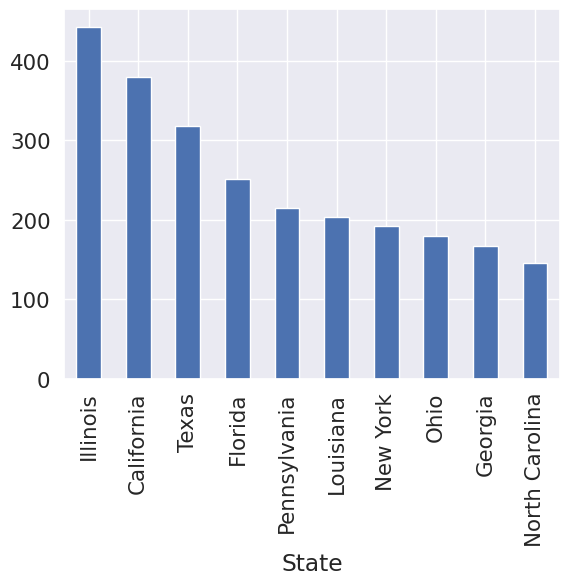

In [52]:
top_states = ms_state_year_laws.groupby('State')['Num Mass Shootings'].sum().sort_values(ascending=False).head(10)
top_states.plot(kind='bar')

# Visualization 4 - Before & After Law Changes

**The visualization shows the average number of mass shootings before and after major firearm law changes, where year 0 is the year the law changes occurred, depicted by the vertical red line. Before the change (years -5 to -1), shootings are fairly stable, staying around 10-12 per year. At year 0, there is a noticeable increase in shootings, and levels stay higher in the years after, with some fluctuation. Overall, mass shooting seem to rise around the time of the law change and stay elevated afterward, with no clear decrease immediately following the policy change.**

Text(0, 0.5, 'Average Number of Shootings')

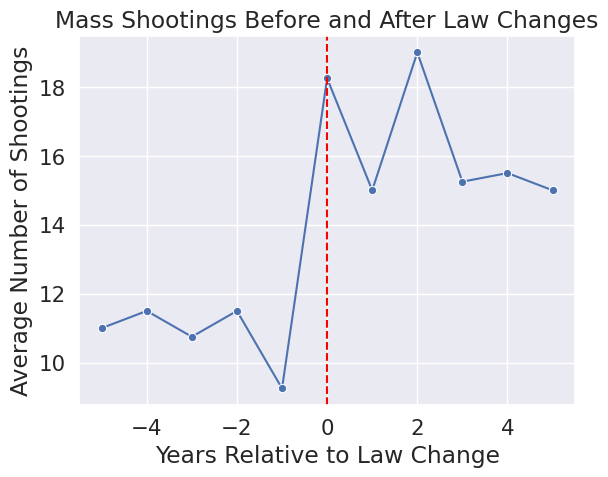

In [53]:
ms_state_year_laws['law_change'] = ms_state_year_laws.groupby('State')['law_count'].diff()
treated_states = ms_state_year_laws[ms_state_year_laws['law_change'] > 5][['State', 'Year']]
treated_states = treated_states.rename(columns={'Year': 'Treatment Year'})
diff_diff_df = pd.merge(ms_state_year_laws, treated_states, on='State', how='left')
diff_diff_df['Event Time'] = diff_diff_df['Year'] - diff_diff_df['Treatment Year']

event_df = diff_diff_df[(diff_diff_df['Event Time'] >= -5) & (diff_diff_df['Event Time'] <= 5)]

avg_effect = event_df.groupby('Event Time')['Num Mass Shootings'].mean().reset_index()

sns.lineplot(data=avg_effect, x='Event Time', y='Num Mass Shootings', marker='o')
plt.axvline(0, linestyle='--', color='red')  # treatment point
plt.title('Mass Shootings Before and After Law Changes')
plt.xlabel('Years Relative to Law Change')
plt.ylabel('Average Number of Shootings')

# Visualization 5 - Annual Mass Shooting Fatalities by State (2015-2023)

**For this visualization, the interactive nature of this time series makes it easy to isolate and track the total number of fatalities in mass shooting incidents in all 50 states. This is helpful for our exploratory data analysis because it combines the number of fatalities in each state with the Giffords Law Rank and Gun Death Rate Rank for each year by state for a comprehensive understanding of the trajectories of each state regarding fatalities and firearm law policy changes over the nine years.**

In [54]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'colab'
state_data = ms_state_year_laws.groupby(['State', 'Year']).agg({'Rank': 'first', 'Gun Death Rate Rank': 'first', 'Num Injured': 'first',
                                                                'Num Killed': 'first', 'Num Mass Shootings': 'first'}).reset_index()
nan_cols = ['Num Killed', 'Num Injured', 'Num Mass Shootings']
state_data[nan_cols] = state_data[nan_cols].fillna(0)
fig = px.line(state_data, x = 'Year', y = 'Num Killed', color = 'State', title = 'Trend of Mass Shooting Fatalities by State (2015 - 2023)', labels = {'Num Killed': 'Victims Killed', 'Year': 'Year'}, markers = True, hover_data = {'Rank': True, 'Gun Death Rate Rank': True})
fig.update_layout(xaxis=dict(rangeslider = dict(visible = True), type = 'linear'), yaxis_title = 'Total Victims Killed', legend_title = 'State', hovermode = 'x unified')
fig.show()
fig.write_html("index.html", include_plotlyjs="cdn")

# Key Takeaways

**For this EDA, we used mass shooting data because we are having issues accessing the K-12 school shooting data, which is what we are mainly focusing on. Later on in the project, we hope to gain access to the proper databases to narrow our scope to school shootings, but this was a good starting point to understand state policy and fatalities. The Folium Map visualization serves as a great representation of the significance of geography and politics on firearm laws. The map shows a clear distinction where strict firearm laws (rank 5) are located in the Northeast and the West Coast, and states with minimal firearm laws are in the South and Midwest (rank 1). This suggests that political views are at work in determining the policies in specific regions. From visualization 2, we were able to gather that there has been an increase in legislative action after 2017-2019, which could suggest that mass shooting events during this time period triggered the number of laws passed. Visualization 3 is where we begin to see that stricter firearm policies might not automatically correlate to less firearm violence. California is among the top 10 states with the highest number of mass shootings, despite having some of the strictest firearm laws. However, it is important to note that Texas is also among the top 10 states, and they have very minimal firearm laws; it could be due to California's large population. From the 4th visualization, it is evident that between -5 and -1 years the average number of shootings remains around 10 to 12 per year, and once there was a change in policy and was enacted, there was an increase in shooting incidents, which demonstrates that policy changes do not instantly mitigate violence. This could also suggest that states that pass the most firearm laws are not effective at stopping a rise in mass shootings. Lastly, visualization 5, shows how there is no specific trend that defines the frequency of fatalities because there are several spikes in the data on various states in different years. Using the Giffords Rank data, this allows us to understand that states with high ranks are not immune to the spikes in mass shootings and affirms that more legislative action against firearms does not completely end mass shootings in those states.**

# <b>MODELING<b>

# Predicting Gun Law Severity from Mass Shooting Statistics

In [56]:
# Aggregating the count of mass shootings per state per year

shooting_counts = (mass_shootings.groupby(['Year', 'State']).size().reset_index(name='Shooting Count'))

# Merge with giffords on Year and State
shooting_counts = shooting_counts.merge(giffords_2015_to_2025[['Year', 'State', 'Rank']], on=['Year', 'State'], how='left')

# Drop rows where we don't have a gun law rank (no giffords data for that state/year)
shooting_counts = shooting_counts.dropna(subset=['Rank'])

In [59]:
shooting_counts['Strength'] = (shooting_counts['Rank'] >= 4).astype(int)

# Trying a Multinomial Logistic Regression Model
**To begin our modeling process, we decided to use multinomial regression because it could utilize the five ranks we established to "grade" the firearm laws. We wanted to see if using the multinomial linear regression through grouping the ranks could help us predict whether the rank of the firearm laws in a specific state has a noticeable effect on mass shootings (which would be our dependent variable). The feature predictor (X) contains a single predictor, which is the shooting count per year. The target variable is the Giffords rank, which is on a scale of 1-5 to assess firearm law severity per state. We split the data into two stages to form a training and testing set, and a training and validation set to conduct logistic regression and find the training and validation accuracy. These accuracies help depict that this classification method did not show a strong relation between the firearm state rankings and mass shootings because the training accuracy was approximately 18.5% and the validation accuracy was approximately 27%, respectively, which are on the lower end. This is most likely due to granularity, because we are trying to classify 5 ranks using a single predictor, which does not allow for a great representation of our data. This is further supported by the confusion matrix, which visually demonstrates that the classifier has a very hard time distinguishing between the ranks solely based off shooting count as a predictor, which indicates that it is time for our group to pivot to another model that may be more successful in enhancing our question of focus.**

In [60]:
#multinomial regression

X = shooting_counts[['Shooting Count']]
y = shooting_counts['Rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, train_size=0.75, test_size=0.25)

logit_model = LogisticRegression(penalty=None, class_weight='balanced')
logit_model.fit(X_train, y_train)

# check the accuracy on the training and validation sets
print("Accuracy on training set: ", logit_model.score(X_train, y_train))
print("Accuracy on validation set: ", logit_model.score(X_validate, y_validate))

Accuracy on training set:  0.21509433962264152
Accuracy on validation set:  0.21348314606741572


In [61]:
predictions = logit_model.predict(X_validate)
probabilities = logit_model.predict_proba(X_validate)

compare = X_validate.copy()
compare['prediction'] = list(predictions) # need to cast as a list because the array above has wrong shape
compare['probability'] = probabilities[:, 1] # the element of the array for probability of true
logit_matrix = metrics.confusion_matrix(y_validate, compare['prediction'])

print("Coefficient:", logit_model.coef_[0][0])
print("Intercept:", logit_model.intercept_[0])
print("\nConfusion Matrix:\n", logit_matrix)
logit_cf_recall = metrics.recall_score(y_validate, compare['prediction'], average='weighted')
logit_cf_precision = metrics.precision_score(y_validate, compare['prediction'], average='weighted')
print("logistic regression classifer recall: ",logit_cf_recall)
print("logistic regression classifer precision: ", logit_cf_precision)

Coefficient: -0.003690649201010899
Intercept: 0.07328295729577454

Confusion Matrix:
 [[ 2  0 21  5 13]
 [ 1  0  3  3  0]
 [ 2  0 11  0  4]
 [ 0  0  5  2  2]
 [ 1  0  9  1  4]]
logistic regression classifer recall:  0.21348314606741572
logistic regression classifer precision:  0.24413542118894901


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Text(86.25, 0.5, 'True Label')

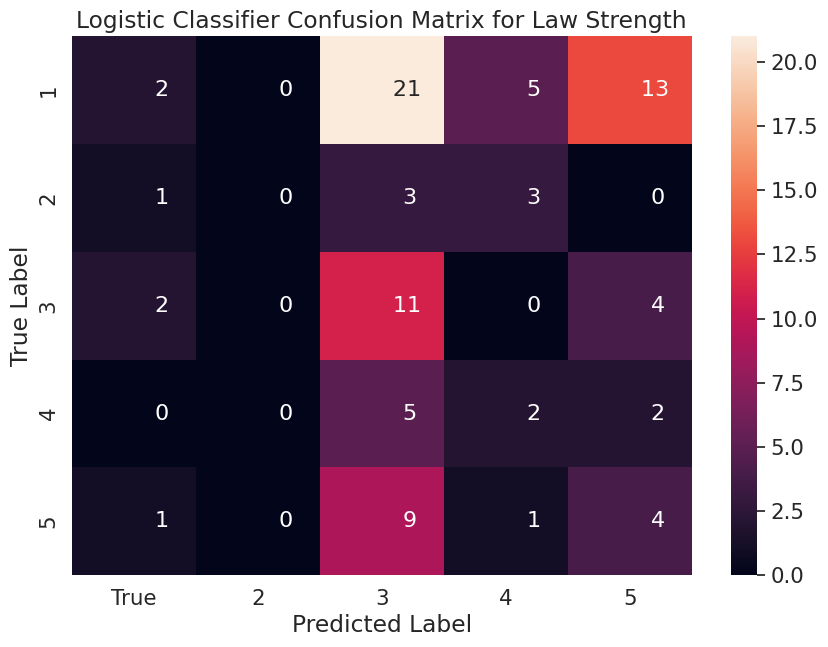

In [62]:
# Display confusion matrix as heatmap
logit_cm = pd.DataFrame(logit_matrix, range(1, 6), range(1, 6))
logit_cm = logit_cm.rename(index=str, columns={0:'False', 1:'True'})
#logit_cm.index = ['False', 'True']
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(logit_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})

plt.title("Logistic Classifier Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Trying a Binomial Logistic Regression Model

**Our previous model didn't work as we hoped. Our goal with multinomial was to capture what we learned from Giffords, and utilize their ranking scale for gun law severity. But actually what we found was that there was really only significance between levels 1 and 5, and not much in 2-4. This led us to decrease the granularity to what we are calling "Strength", One Hot Encoded as 0 and 1: levels 1-3 being 0, and levels 4-5 being 1. In doing so, we realize the extent of granularity we are getting rid of. From taking the letter grades of Giffords and turning them from an A-D scale including +- values, to a 1-5 scale, and now down to 0-1. But what we have learned from this is that the middling levels of law severity aren't significant predictors of mass shootings, but rather relative strength. To investigate "Strength" as a valid variable within modeling, we now plan to see if state control (congressional control and governor party) per year can help predict both state strength in gun laws, and amounts of mass shootings. We recognize that this might be telling us something a little more black and white: if a state's congressional party control and governance control has more of an effect on gun law strength, and if that in turn defines how many mass shootings occur in a given year. This could lead us to the result of state control being a primary indicator of a lot of the factors that go into mass shootings, as we have discussed guns as only being a part. In our final presentation we may even want to look into mental health resources as associated with state party control as another factor in mass shootings occurring.**

In [63]:
# the data we're working with (binomial logistic regression)

X = shooting_counts[['Shooting Count']]
y = shooting_counts['Strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, train_size=0.75, test_size=0.25)

In [64]:
logit_model = LogisticRegression(penalty=None, class_weight='balanced')
logit_model.fit(X_train, y_train)

# check the accuracy on the training and validation sets
print("Accuracy on training set: ", logit_model.score(X_train, y_train))
print("Accuracy on validation set: ", logit_model.score(X_validate, y_validate))

Accuracy on training set:  0.5924528301886792
Accuracy on validation set:  0.5730337078651685


In [65]:
predictions = logit_model.predict(X_validate)
probabilities = logit_model.predict_proba(X_validate)

compare = X_validate.copy()
compare['prediction'] = list(predictions) # need to cast as a list because the array above has wrong shape
compare['probability'] = probabilities[:, 1] # the element of the array for probability of true
logit_matrix = metrics.confusion_matrix(y_validate, compare['prediction'])

print("Coefficient:", logit_model.coef_[0][0])
print("Intercept:", logit_model.intercept_[0])
print("\nConfusion Matrix:\n", logit_matrix)
logit_cf_recall = metrics.recall_score(y_validate, compare['prediction'])
logit_cf_precision = metrics.precision_score(y_validate, compare['prediction'])
logit_cf_auc_roc_score = metrics.roc_auc_score(y_validate, compare['prediction'])
print("logistic regression classifer recall: ",logit_cf_recall)
print("logistic regression classifer precision: ", logit_cf_precision)
print("logistic regression classifer AUC-ROC score: ", logit_cf_auc_roc_score)

Coefficient: 0.027979691947134542
Intercept: -0.35905277704607347

Confusion Matrix:
 [[39 18]
 [20 12]]
logistic regression classifer recall:  0.375
logistic regression classifer precision:  0.4
logistic regression classifer AUC-ROC score:  0.5296052631578947


Text(86.25, 0.5, 'True Label')

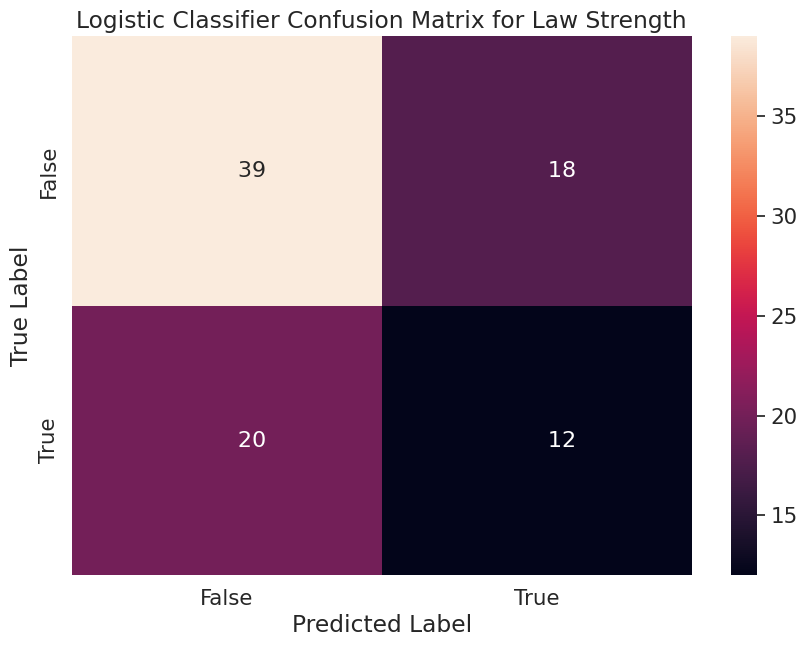

In [66]:
# Display confusion matrix as heatmap
logit_cm = pd.DataFrame(logit_matrix, range(2), range(2))
logit_cm = logit_cm.rename(index=str, columns={0:'False', 1:'True'})
logit_cm.index = ['False', 'True']
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(logit_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})

plt.title("Logistic Classifier Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Predicting Rank With State-Control Data

**Because our data was incompatible with both the multinomial and binomial logistic regression models (due to the small number of observations and the granularity of the data), we wanted to see if we could get stronger predictions for gun law strength by including data on state-government control. We began with another logistic regression model using the state-control data, which gave us insights into the makeup of the state legislature that could potentially influence what restrictions or laws were passed on firearms. One big difference between our binary logistic regression models is that with the state-control data included, our model predicted significantly less False Positives (predicted a state had strong laws but actually didn't) than the data that was solely based on shooting counts per state per year. To investigate a bit deeper, we also created a Random Forest Classifier to understand non-linear relationships between our predictors without any underlying assumptions. The Random Forest's biggest benefit was allowing us to look at feature importances. We discovered that of the predictors we used for our model (`['Shooting Count', 'State Control_R', 'State Control_S']`), `State Control_R` had a feature importance of around 0.623, whereas our initial predictor, `Shooting Count`,only had an importance of around 0.309 (based on one iteration. We did not set a random seed for this portion so numbers can be off on a certain run). This tells us that State Control is a much stronger signal to a state's gun law strength than just the number of shootings per state per year. Going forward, we will combine the state-control data, the Giffords ranking data, and RAND's laws database to further strengthen our model and understand what other factors influence our model's ability to detect whether a state has more stringent firearm laws or not.**

In [73]:
#merge all the dfs

merge_all = pd.merge(merged_pd, shooting_counts, on=['State', 'Year'], how='inner')

merge_all = merge_all[merge_all['State Control'] != 'N/A']

merged_controls = pd.get_dummies(merge_all, columns=['State Control'], drop_first=True)

In [77]:
X = merged_controls[['Shooting Count', 'State Control_R', 'State Control_S']]
y = merged_controls['Strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, train_size=0.75, test_size=0.25)

logit_multi_model = LogisticRegression(penalty=None, class_weight='balanced')
logit_multi_model.fit(X_train, y_train)
print("Accuracy on training set: ", logit_multi_model.score(X_train, y_train))
print("Accuracy on validation set: ", logit_multi_model.score(X_validate, y_validate))

Accuracy on training set:  0.85
Accuracy on validation set:  0.8620689655172413


Text(86.25, 0.5, 'True Label')

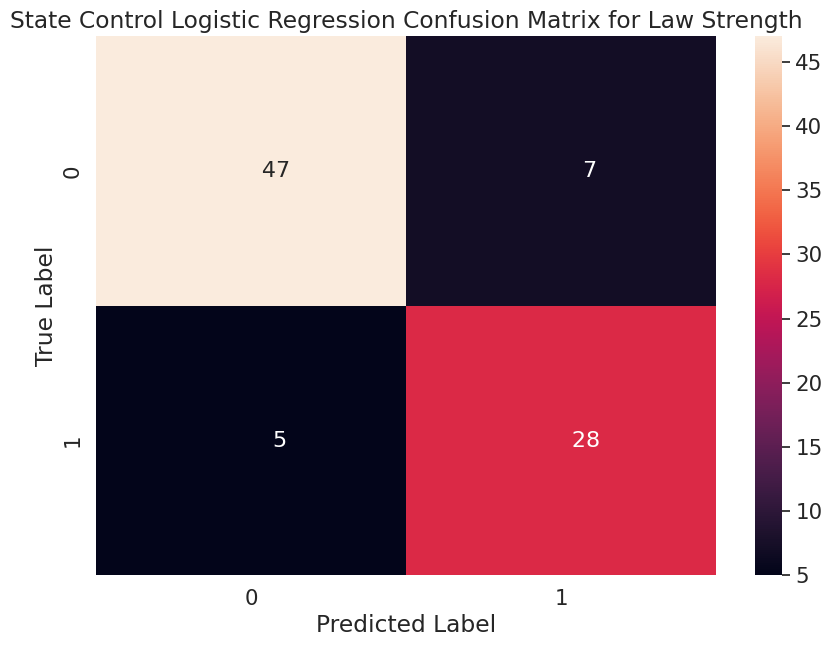

In [78]:
predictions = logit_multi_model.predict(X_validate)
logit_matrix = metrics.confusion_matrix(y_validate, predictions)

logit_cm = pd.DataFrame(logit_matrix, range(2), range(2))

plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(logit_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})
plt.title("State Control Logistic Regression Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("Accuracy on training set: ", rf_model.score(X_train, y_train))
print("Accuracy on validation set: ", rf_model.score(X_validate, y_validate))

Accuracy on training set:  0.9
Accuracy on validation set:  0.8275862068965517


Text(86.25, 0.5, 'True Label')

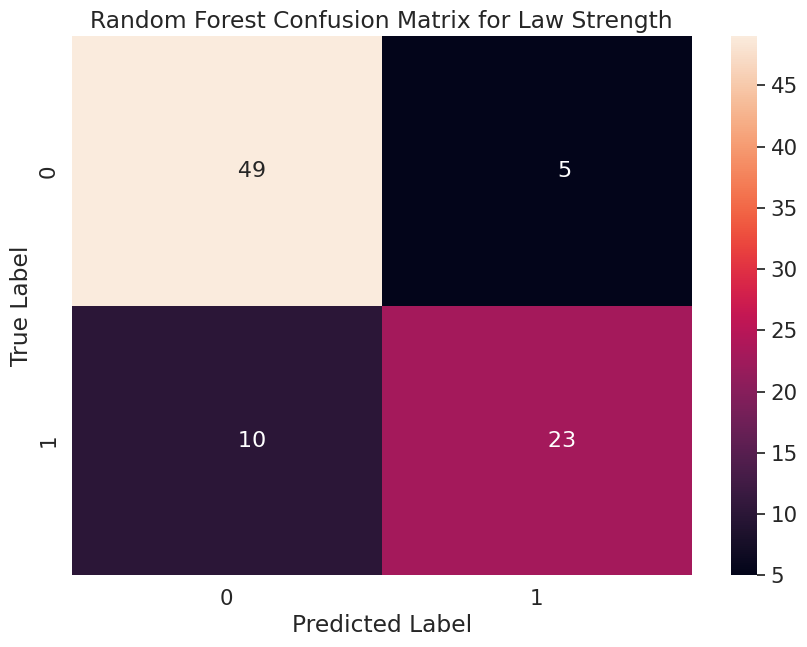

In [80]:
predictions_rf = rf_model.predict(X_validate)
rf_matrix = metrics.confusion_matrix(y_validate, predictions_rf)

rf_cm = pd.DataFrame(rf_matrix, range(2), range(2))

plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(rf_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})
plt.title("Random Forest Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

In [81]:
#Feature Importances

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)


Feature Importances:
 State Control_R    0.622718
Shooting Count     0.309717
State Control_S    0.067565
dtype: float64


In [82]:
corr_cols = ['State Control_R', 'State Control_S', 'Shooting Count', 'Rank_y', 'Strength']
corr_matrix = merged_controls[corr_cols].corr()
corr_matrix

,State Control_R,State Control_S,Shooting Count,Rank_y,Strength
State Control_R,1.000000,-0.590180,-0.015843,-0.697731,-0.622925
State Control_S,-0.590180,1.000000,-0.034316,0.138620,0.072225
Shooting Count,-0.015843,-0.034316,1.000000,0.156985,0.161140
Rank_y,-0.697731,0.138620,0.156985,1.000000,0.890967
Strength,-0.622925,0.072225,0.161140,0.890967,1.000000
